## Exploreatory Data Analysis
### In this section we will insepect the data to see the pattern of transection process
- plot the time series with revenues & total transection per months
- Numbers of Transection per months & days and hours
- Top 12 Countries by revenue 
- Top 15 products by revenue & total sold
- checkout the finding in the end of the notebook

In [1]:
#import library and ignore warning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
#load the cvs file and check header
customers = pd.read_csv('../data/processed/online_retail_clean.csv')

customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [3]:
customers.dtypes

InvoiceNo        int64
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID       int64
Country         object
TotalSpend     float64
dtype: object

## Create A necessary columns for Data Visualization

In [4]:
# 2. Time-based Analysis

customers['InvoiceDate'] = pd.to_datetime(customers['InvoiceDate'])

# Extract useful date parts
customers['InvoiceYearMonth'] = customers['InvoiceDate'].dt.to_period('M')
customers['InvoiceDateOnly'] = customers['InvoiceDate'].dt.date
customers['InvoiceDayOfWeek'] = customers['InvoiceDate'].dt.day_name()
customers['InvoiceHour'] = customers['InvoiceDate'].dt.hour

#check the dataframe again

customers.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,InvoiceYearMonth,InvoiceDateOnly,InvoiceDayOfWeek,InvoiceHour
211712,563558,84509A,set of 4 english rose placemats,4,2011-08-17 13:40:00,3.75,14156,EIRE,15.00,2011-08,2011-08-17,Wednesday,13
258002,568577,85135B,blue dragonfly helicopter,3,2011-09-28 09:41:00,7.95,15301,United Kingdom,23.85,2011-09,2011-09-28,Wednesday,9
306806,573185,23504,playing cards jubilee union jack,12,2011-10-28 11:34:00,1.25,17730,United Kingdom,15.00,2011-10,2011-10-28,Friday,11
178294,559665,22499,wooden union jack bunting,1,2011-07-11 13:35:00,5.95,12556,Spain,5.95,2011-07,2011-07-11,Monday,13
293983,572035,22492,mini paint set vintage,576,2011-10-20 12:03:00,0.55,14646,Netherlands,316.80,2011-10,2011-10-20,Thursday,12
333850,575851,21945,strawberries design flannel,1,2011-11-11 12:13:00,0.85,14662,United Kingdom,0.85,2011-11,2011-11-11,Friday,12
210478,563434,22988,soldiers egg cup,12,2011-08-16 12:21:00,1.25,14057,United Kingdom,15.00,2011-08,2011-08-16,Tuesday,12
153727,556467,21466,red flower crochet food cover,1,2011-06-12 11:17:00,3.75,13232,United Kingdom,3.75,2011-06,2011-06-12,Sunday,11
160379,557268,22607,wooden rounders garden set,1,2011-06-19 11:26:00,9.95,13097,United Kingdom,9.95,2011-06,2011-06-19,Sunday,11
218332,564231,84879,assorted colour bird ornament,8,2011-08-24 10:22:00,1.69,13468,United Kingdom,13.52,2011-08,2011-08-24,Wednesday,10


### Line Chart for Monthly Transactions & Revenue 

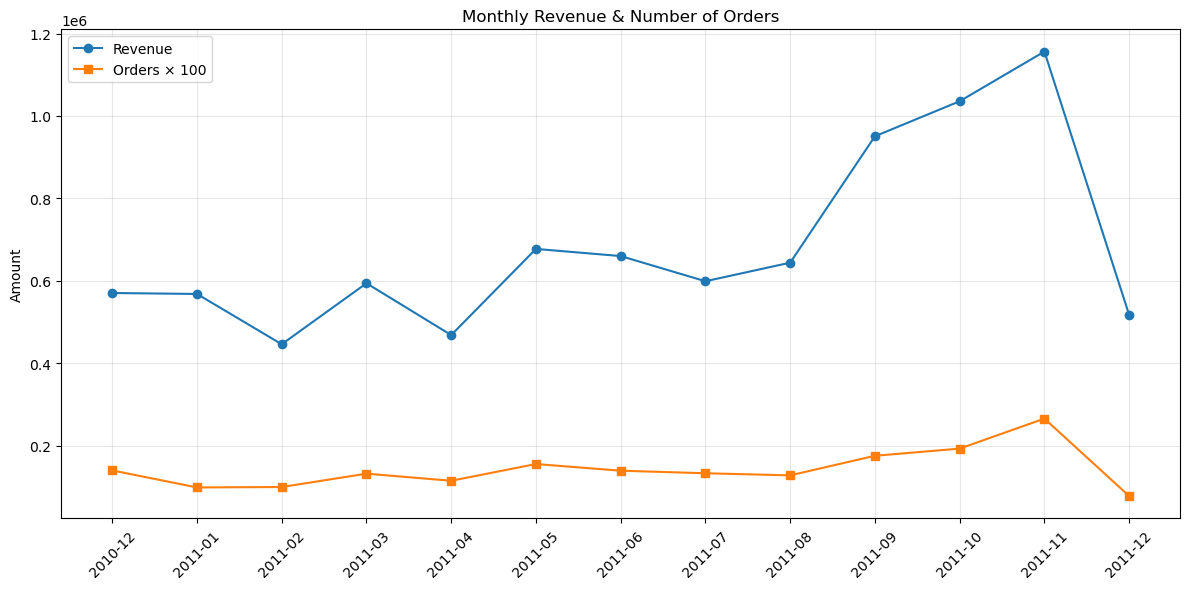

In [5]:
# ─── Monthly transactions & revenue ───
# Create monthly aggregation including operation days
monthly = customers.groupby('InvoiceYearMonth').agg({
    'InvoiceNo': 'nunique',           # number of unique orders
    'TotalSpend': 'sum',              # total revenue
    'CustomerID': 'nunique',          # unique customers
    'InvoiceDate': lambda x: x.dt.date.nunique()  # count of unique operational days
}).reset_index()

# Rename the new column
monthly.rename(columns={'InvoiceDate':'OperationDays'}, inplace=True)

monthly['InvoiceYearMonth'] = monthly['InvoiceYearMonth'].astype(str)  # for plotting

plt.figure(figsize=(12, 6))
plt.plot(monthly['InvoiceYearMonth'], monthly['TotalSpend'], marker='o', label='Revenue')
plt.plot(monthly['InvoiceYearMonth'], monthly['InvoiceNo'] * 100, marker='s', label='Orders × 100')  # scaled for visibility
plt.xticks(rotation=45)
plt.title('Monthly Revenue & Number of Orders')
plt.ylabel('Amount')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
monthly

,InvoiceYearMonth,InvoiceNo,TotalSpend,CustomerID,OperationDays
0,2010-12,1400,570422.730,885,20
1,2011-01,987,568101.310,741,24
2,2011-02,997,446084.920,758,24
3,2011-03,1321,594081.760,974,27
4,2011-04,1149,468374.331,856,21
5,2011-05,1555,677355.150,1056,25
6,2011-06,1393,660046.050,991,26
7,2011-07,1331,598962.901,949,26
8,2011-08,1280,644051.040,935,26
9,2011-09,1755,950690.202,1266,26


### Number of Operation day on each month

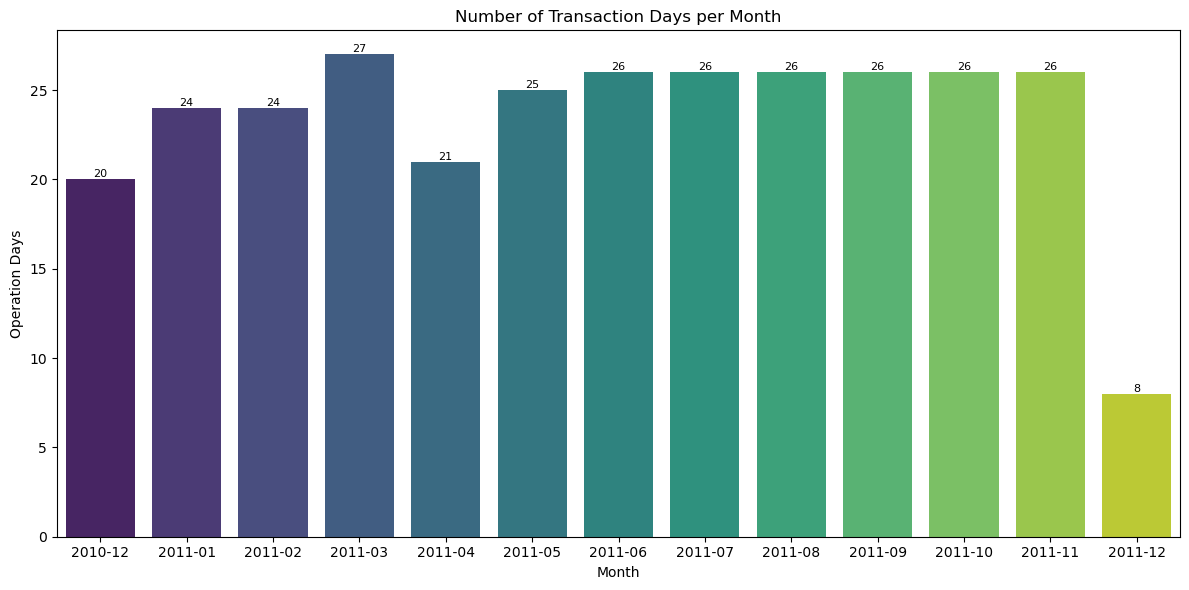

In [7]:
#plot the bar graph distribution of each months operation day

plt.figure(figsize=(12,6))
ax = sns.barplot(data=monthly, y='OperationDays', x='InvoiceYearMonth', palette='viridis')

plt.title("Number of Transaction Days per Month")
plt.xlabel("Month")
plt.ylabel("Operation Days")

# Add value labels on bars
for i in ax.containers:
    ax.bar_label(i, fontsize=8)

plt.tight_layout()
plt.show()

### Transaction per day in a week

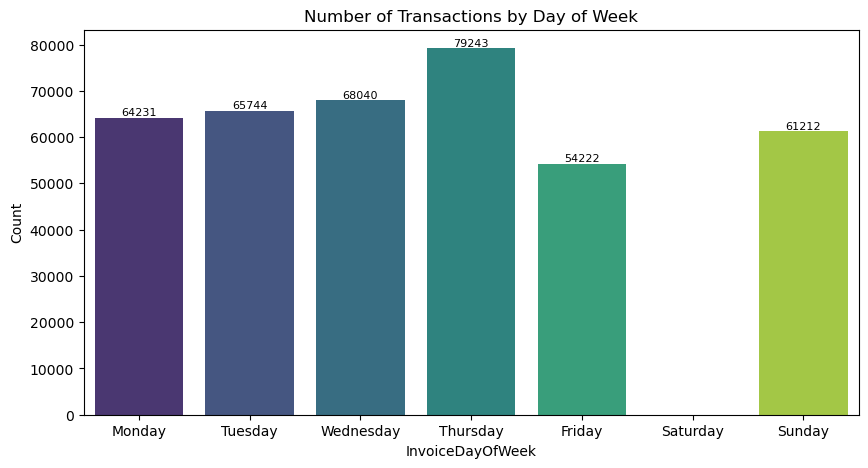

In [8]:
# ─── Day of week pattern ───
dow_order = customers['InvoiceDayOfWeek'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=dow_order.index, y=dow_order.values, palette='viridis')
# Add value labels on bars
for i in ax.containers:
    ax.bar_label(i, fontsize=8)

plt.title('Number of Transactions by Day of Week')
plt.ylabel('Count')
plt.show()

### Transactions by hour of Day (operated hours)

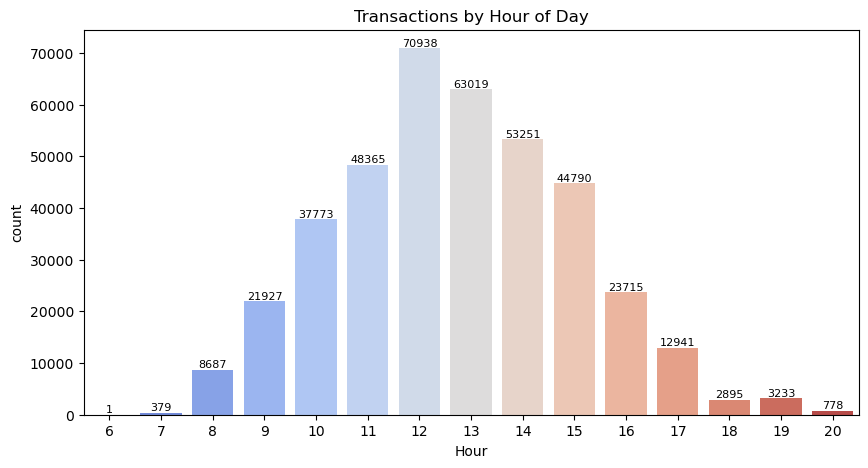

In [9]:
# ─── Hour of day pattern ───
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='InvoiceHour', data=customers, palette='coolwarm')
# Add value labels on bars
for i in ax.containers:
    ax.bar_label(i, fontsize=8)
    
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour')
plt.show()

## Country

In [10]:
# 3. Geographical Insights

# ─── Transactions & Revenue by Country ───
country_summary = customers.groupby('Country').agg({
    'InvoiceNo': 'nunique',
    'TotalSpend': 'sum',
    'CustomerID': 'nunique'
}).reset_index()

country_summary = country_summary.sort_values('TotalSpend', ascending=False)
country_summary.head()

,Country,InvoiceNo,TotalSpend,CustomerID
35,United Kingdom,16646,7285024.644,3920
23,Netherlands,94,285446.340,9
10,EIRE,260,265262.460,3
14,Germany,457,228678.400,94
13,France,389,208934.310,87


### Top 10 Country by revenue

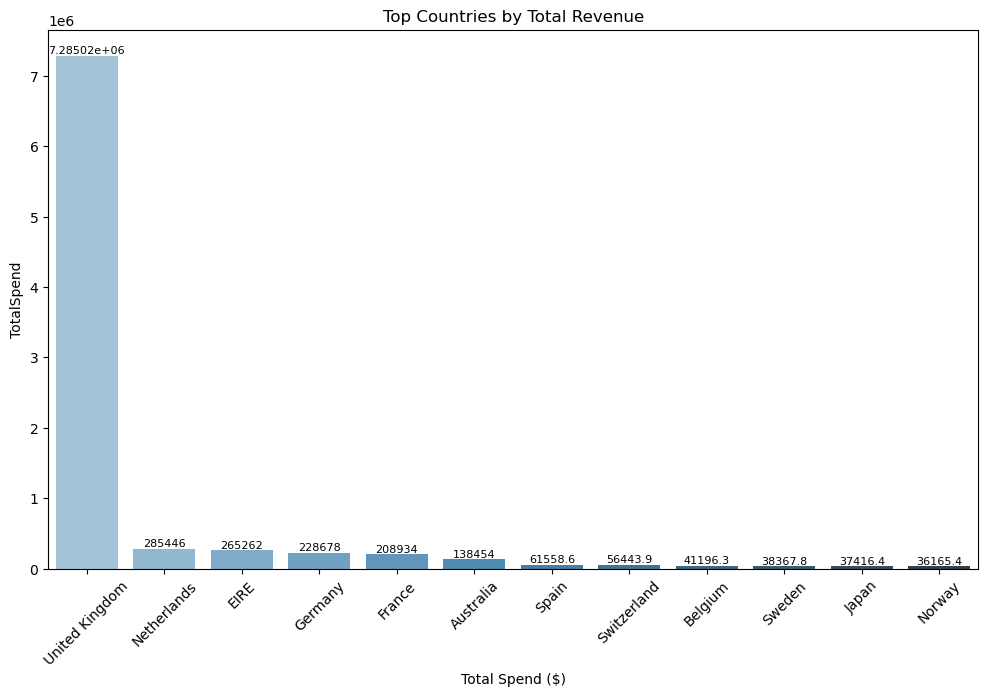

In [11]:
# Top 10 countries by revenue
top_countries = country_summary.head(12)  # usually UK dominates

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_countries, y='TotalSpend', x='Country', palette='Blues_d')
# Add value labels on bars
for i in ax.containers:
    ax.bar_label(i, fontsize=8)
    
plt.title('Top Countries by Total Revenue')
plt.xlabel('Total Spend ($)')
plt.xticks(rotation=45)
plt.show()

### Top 15 Products by Quantity Sold

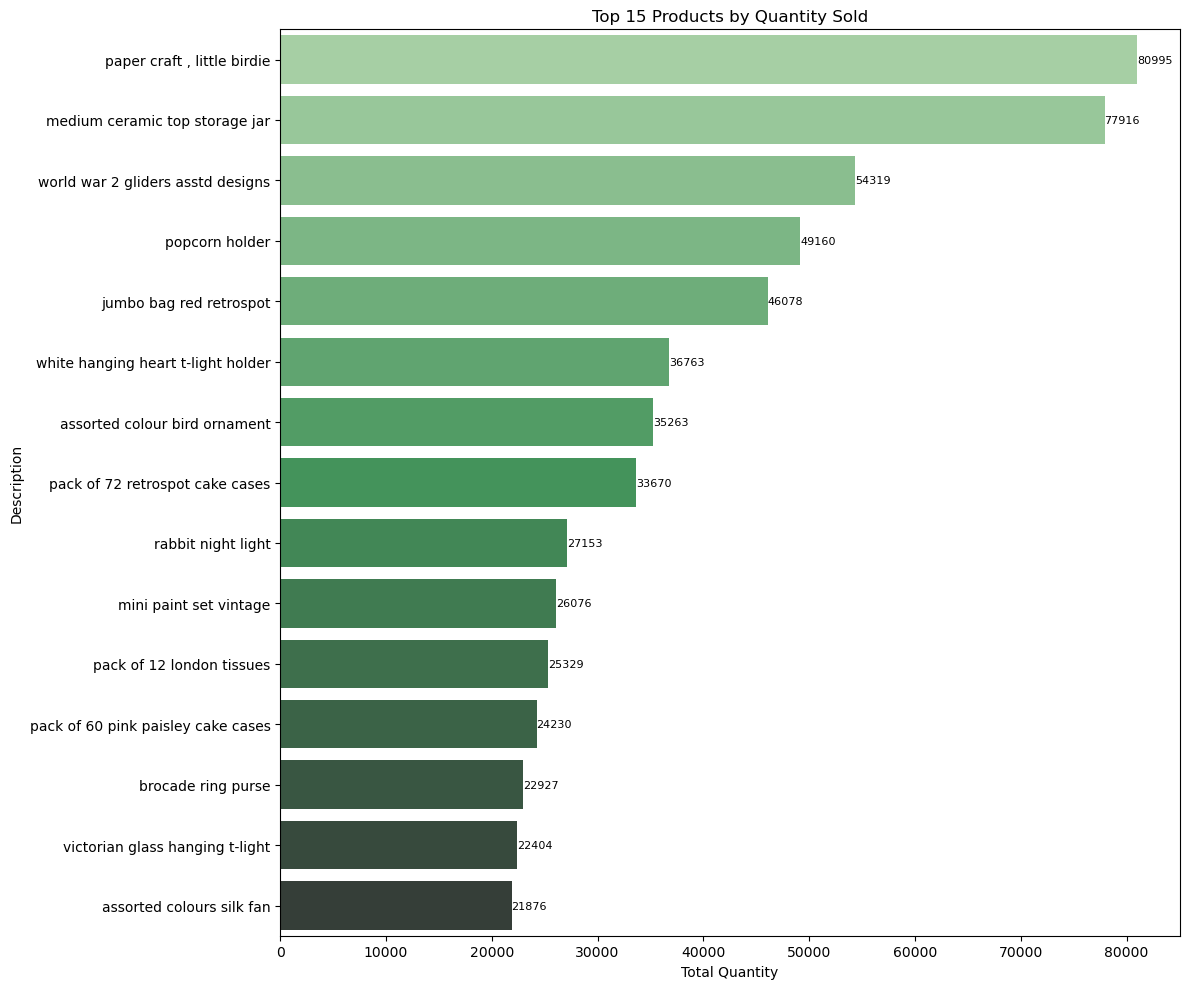

In [12]:
# Top 15 products by quantity
top_products_qty = customers.groupby(['Description'])['Quantity'].sum()\
                     .sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(12,10))
ax = sns.barplot(data=top_products_qty, x='Quantity', y='Description', palette='Greens_d')

plt.title('Top 15 Products by Quantity Sold')
plt.xlabel('Total Quantity')

# Add value labels on bars
for i in ax.containers:
    ax.bar_label(i, fontsize=8)

plt.tight_layout()
plt.show()

### Top 15 Products by Revenue

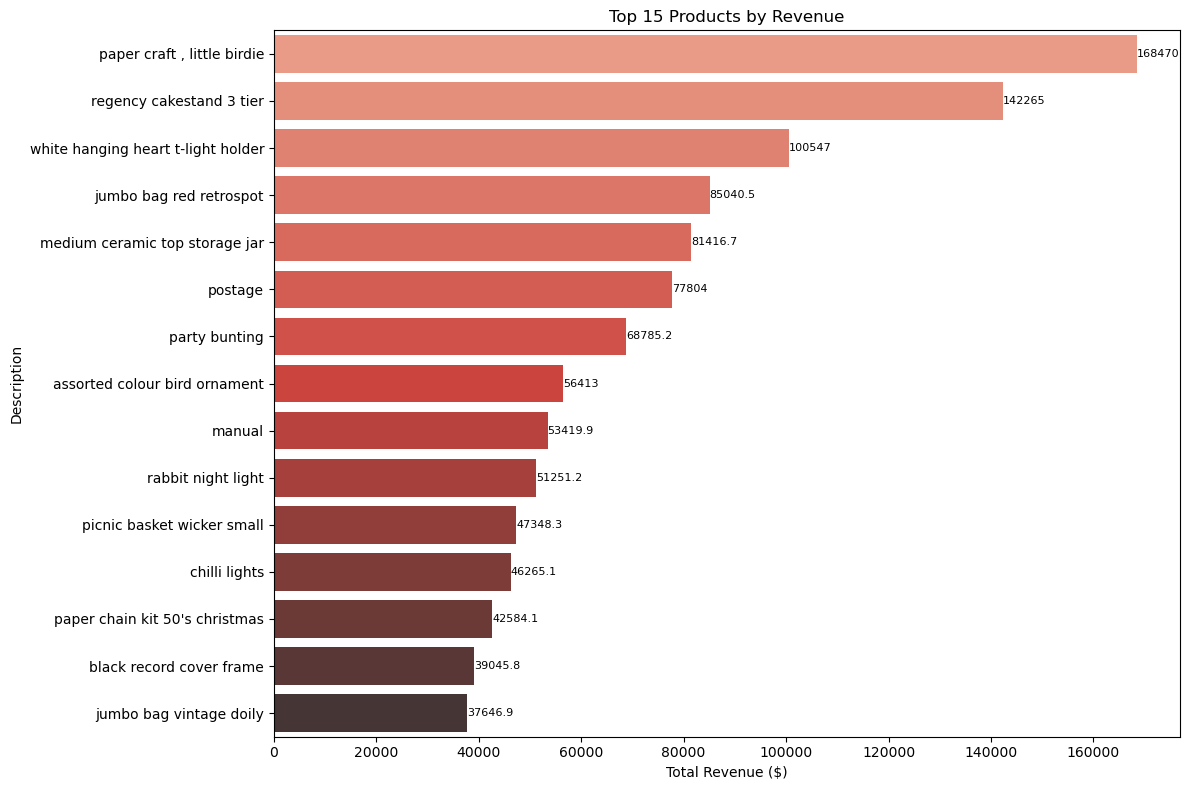

In [13]:
# ─── Top 15 products by revenue ───
top_products_rev = customers.groupby(['Description'])['TotalSpend'].sum()\
                     .sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=top_products_rev, x='TotalSpend', y='Description', palette='Reds_d')

# Add value labels on bars
for i in ax.containers:
    ax.bar_label(i, fontsize=8)
    
plt.title('Top 15 Products by Revenue')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

In [14]:
#check the header of dataset that we have create some new columns for EDA
customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,InvoiceYearMonth,InvoiceDateOnly,InvoiceDayOfWeek,InvoiceHour
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12-01,Wednesday,8
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12-01,Wednesday,8
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8


In [15]:
#load data into csv file
#save dataset after do EDA
customers.to_csv("../data/processed/online_retail_final.csv", index=False)

## Finding
- Revenue & Sell on December 2011 not actually drop becuase of we cannot sold any products but due to dataset that contain only 8 operations day
- Every Saturday the store don't sell or do any operation
- According to the transaction by Hours we realize the store operate from 6:00am to 9:00pm on Sun - Friday
- The peak time of transection are around 12- 2:00pm which indicated to lunch time
- Country that purchase the most are United Kingdom
- While the top 1 categorices on both Revenue & Quantity sold is Paper Craft, Little Bridle